In [1]:
import pandas as pd


In [2]:
df = pd.read_csv("../data/raw/activities.csv")


In [3]:
df.shape


(647, 99)

In [4]:
df.columns


Index(['Activity ID', 'Activity Date', 'Activity Name', 'Activity Type',
       'Activity Description', 'Elapsed Time', 'Distance', 'Max Heart Rate',
       'Relative Effort', 'Commute', 'Activity Private Note', 'Activity Gear',
       'Filename', 'Athlete Weight', 'Bike Weight', 'Elapsed Time.1',
       'Moving Time', 'Distance.1', 'Max Speed', 'Average Speed',
       'Elevation Gain', 'Elevation Loss', 'Elevation Low', 'Elevation High',
       'Max Grade', 'Average Grade', 'Average Positive Grade',
       'Average Negative Grade', 'Max Cadence', 'Average Cadence',
       'Max Heart Rate.1', 'Average Heart Rate', 'Max Watts', 'Average Watts',
       'Calories', 'Max Temperature', 'Average Temperature',
       'Relative Effort.1', 'Total Work', 'Number of Runs', 'Uphill Time',
       'Downhill Time', 'Other Time', 'Perceived Exertion', 'Type',
       'Start Time', 'Weighted Average Power', 'Power Count',
       'Prefer Perceived Exertion', 'Perceived Relative Effort', 'Commute.1',
    

In [5]:
df.head()


,Activity ID,Activity Date,Activity Name,Activity Type,Activity Description,Elapsed Time,Distance,Max Heart Rate,Relative Effort,Commute,...,Intensity,Average Grade Adjusted Pace,Timer Time,Total Cycles,Recovery,With Pet,Competition,Long Run,For a Cause,Media
0,3357552652,"Apr 26, 2020, 3:20:32 PM",Lunch Ride,Ride,NaN,4735,21.37,NaN,NaN,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,3366490362,"Apr 28, 2020, 3:41:08 PM",Neighborhood,Run,"Killing time, shitty headphones",708,1.61,NaN,NaN,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3377049691,"Apr 30, 2020, 9:02:45 PM",Need 4 speed,Run,"Windy, after squats. Stopped 4 times",1066,1.61,NaN,NaN,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3381788346,"May 1, 2020, 7:36:16 PM",S and p,Ride,So windy,3381,16.45,NaN,NaN,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,3394020715,"May 3, 2020, 9:32:24 PM",2 fast,Run,Lol,1648,3.23,NaN,NaN,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
df["Activity Type"].value_counts()


Activity Type
Run                401
Walk               101
Stair-Stepper       61
Yoga                43
Workout             27
Ride                 8
Inline Skate         3
Weight Training      2
Kayaking             1
Name: count, dtype: int64

In [7]:
runs_df = df[df["Activity Type"] == "Run"]
runs_df.shape


(401, 99)

Definition:
Long runs are defined as running activities with a distance of 9 miles or greater. This threshold corresponds to approximately the 75th percentile of run distances in the dataset.

In [10]:
long_runs_df = runs_df[runs_df["Distance"] >= 9]
long_runs_df.shape


(97, 99)

In [11]:
non_long_runs_df = runs_df[runs_df["Distance"] < long_run_threshold]


NameError: name 'long_run_threshold' is not defined

In [12]:
long_run_threshold = 9


In [13]:
long_runs_df = runs_df[runs_df["Distance"] >= long_run_threshold]
non_long_runs_df = runs_df[runs_df["Distance"] < long_run_threshold]


In [14]:
long_runs_df.shape, non_long_runs_df.shape


((97, 99), (304, 99))

In [15]:
long_hr_mean = long_runs_df["Average Heart Rate"].mean()
non_long_hr_mean = non_long_runs_df["Average Heart Rate"].mean()

long_hr_mean, non_long_hr_mean


(151.79775280898878, 151.90035587188612)

## Insight 1: Long Runs Are Not Run at Higher Intensity

Long runs were defined as runs at or above the 75th percentile of distance (≥ 9 miles).

Despite longer distance, the average heart rate for long runs (151.8 bpm) was nearly identical to non-long runs (151.9 bpm). This suggests that long runs are being executed at a controlled aerobic intensity rather than creeping into higher-effort training zones.

This consistency indicates strong endurance discipline and an aerobic base capable of sustaining longer distances without increased cardiovascular strain.


In [16]:
easy_runs_df = runs_df[runs_df["Average Heart Rate"] <= 154]


In [17]:
easy_runs_df.shape


(228, 99)

In [18]:
import matplotlib.pyplot as plt

plt.scatter(
    easy_runs_df["Distance"],
    easy_runs_df["Average Pace"]
)
plt.xlabel("Distance (miles)")
plt.ylabel("Average Pace")
plt.title("Pace vs Distance at Controlled Heart Rate (≤154 BPM)")
plt.show()


Matplotlib is building the font cache; this may take a moment.


KeyError: 'Average Pace'

In [ ]:
easy_runs_df[["Distance", "Average Pace"]].corr()


In [19]:
easy_runs_df.columns


Index(['Activity ID', 'Activity Date', 'Activity Name', 'Activity Type',
       'Activity Description', 'Elapsed Time', 'Distance', 'Max Heart Rate',
       'Relative Effort', 'Commute', 'Activity Private Note', 'Activity Gear',
       'Filename', 'Athlete Weight', 'Bike Weight', 'Elapsed Time.1',
       'Moving Time', 'Distance.1', 'Max Speed', 'Average Speed',
       'Elevation Gain', 'Elevation Loss', 'Elevation Low', 'Elevation High',
       'Max Grade', 'Average Grade', 'Average Positive Grade',
       'Average Negative Grade', 'Max Cadence', 'Average Cadence',
       'Max Heart Rate.1', 'Average Heart Rate', 'Max Watts', 'Average Watts',
       'Calories', 'Max Temperature', 'Average Temperature',
       'Relative Effort.1', 'Total Work', 'Number of Runs', 'Uphill Time',
       'Downhill Time', 'Other Time', 'Perceived Exertion', 'Type',
       'Start Time', 'Weighted Average Power', 'Power Count',
       'Prefer Perceived Exertion', 'Perceived Relative Effort', 'Commute.1',
    

In [20]:
easy_runs_df["Average Pace"] = 60 / easy_runs_df["Average Speed"]


/var/folders/yr/73yp9km52b9ckwk77nj4x3yr0000gn/T/ipykernel_10951/451204129.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  easy_runs_df["Average Pace"] = 60 / easy_runs_df["Average Speed"]


In [21]:
easy_runs_df = easy_runs_df.copy()
easy_runs_df["Average Pace"] = 60 / easy_runs_df["Average Speed"]


In [22]:
easy_runs_df["Average Pace"].describe()


count    228.000000
mean      22.884961
std        6.892357
min       13.824885
25%       21.093356
50%       22.050720
75%       22.731600
max       88.757396
Name: Average Pace, dtype: float64

In [23]:
easy_runs_df["Average Pace"] = 26.8224 / easy_runs_df["Average Speed"]


In [24]:
easy_runs_df["Average Pace"].describe()


count    228.000000
mean      10.230493
std        3.081159
min        6.180276
25%        9.429574
50%        9.857554
75%       10.161934
max       39.678107
Name: Average Pace, dtype: float64

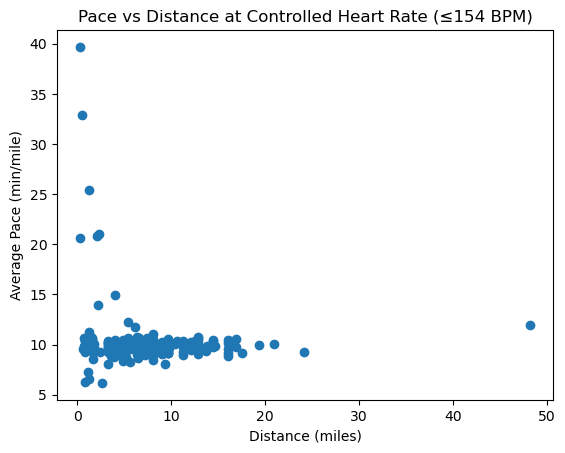

In [25]:
import matplotlib.pyplot as plt

plt.scatter(
    easy_runs_df["Distance"],
    easy_runs_df["Average Pace"]
)
plt.xlabel("Distance (miles)")
plt.ylabel("Average Pace (min/mile)")
plt.title("Pace vs Distance at Controlled Heart Rate (≤154 BPM)")
plt.show()


In [26]:
easy_runs_df[["Distance", "Average Pace"]].corr()


,Distance,Average Pace
Distance,1.000000,-0.138251
Average Pace,-0.138251,1.000000


## Insight 2: Pace Remains Stable Across Distance at Controlled Effort

To control for effort, runs were filtered to those with an average heart rate ≤ 154 BPM, aligning with easy-run training guidelines.

Across these runs, average pace remained relatively stable as distance increased. The correlation between distance and pace was weak (r = -0.14), indicating that longer distances did not meaningfully slow pace when effort was held constant.

This suggests strong aerobic efficiency, where increased distance can be sustained without significant degradation in performance output.


In [27]:
runs_df.columns


Index(['Activity ID', 'Activity Date', 'Activity Name', 'Activity Type',
       'Activity Description', 'Elapsed Time', 'Distance', 'Max Heart Rate',
       'Relative Effort', 'Commute', 'Activity Private Note', 'Activity Gear',
       'Filename', 'Athlete Weight', 'Bike Weight', 'Elapsed Time.1',
       'Moving Time', 'Distance.1', 'Max Speed', 'Average Speed',
       'Elevation Gain', 'Elevation Loss', 'Elevation Low', 'Elevation High',
       'Max Grade', 'Average Grade', 'Average Positive Grade',
       'Average Negative Grade', 'Max Cadence', 'Average Cadence',
       'Max Heart Rate.1', 'Average Heart Rate', 'Max Watts', 'Average Watts',
       'Calories', 'Max Temperature', 'Average Temperature',
       'Relative Effort.1', 'Total Work', 'Number of Runs', 'Uphill Time',
       'Downhill Time', 'Other Time', 'Perceived Exertion', 'Type',
       'Start Time', 'Weighted Average Power', 'Power Count',
       'Prefer Perceived Exertion', 'Perceived Relative Effort', 'Commute.1',
    

In [32]:
# Convert Activity Date to datetime
easy_runs_df['Date'] = pd.to_datetime(easy_runs_df['Activity Date'])


/var/folders/yr/73yp9km52b9ckwk77nj4x3yr0000gn/T/ipykernel_10951/463996782.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  easy_runs_df['Date'] = pd.to_datetime(easy_runs_df['Activity Date'])


In [33]:
easy_runs_df['Activity Date'].head()


22    Aug 13, 2023, 10:53:13 PM
24     Aug 16, 2023, 9:17:05 AM
27     Aug 20, 2023, 9:37:25 PM
33     Aug 27, 2023, 9:50:03 PM
35      Sep 2, 2023, 1:44:38 PM
Name: Activity Date, dtype: object

In [34]:
easy_runs_df['Date'] = pd.to_datetime(
    easy_runs_df['Activity Date'], 
    format='%b %d, %Y, %I:%M:%S %p'
)


In [35]:
easy_runs_df = easy_runs_df.sort_values('Date')
easy_runs_df['Month'] = easy_runs_df['Date'].dt.to_period('M')
monthly_avg = easy_runs_df.groupby('Month')['Average Pace'].mean().reset_index()


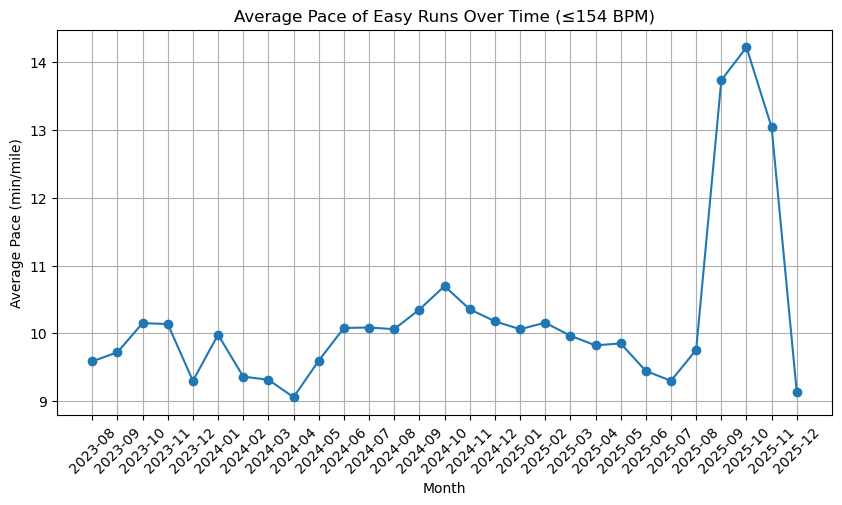

In [36]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(monthly_avg['Month'].astype(str), monthly_avg['Average Pace'], marker='o')
plt.xticks(rotation=45)
plt.xlabel("Month")
plt.ylabel("Average Pace (min/mile)")
plt.title("Average Pace of Easy Runs Over Time (≤154 BPM)")
plt.grid(True)
plt.show()


## Insight 3: Aerobic Efficiency Is Stable Over Time With Post-Ultra Recovery Effects

Average pace of easy-effort runs (≤154 BPM) was tracked over time to evaluate long-term aerobic efficiency.

Across most of the observed period, average pace remained stable around 9.5–10.5 min/mile, indicating durable aerobic efficiency under a controlled effort constraint.

A notable slowdown was observed in late 2025. This period coincided with the completion of two ultra-marathon events, suggesting that the temporary increase in easy-run pace reflects accumulated fatigue and recovery effects rather than a decline in aerobic fitness. Pace returned toward baseline in subsequent months, reinforcing this interpretation.

This pattern highlights the importance of contextual training factors when interpreting longitudinal per


In [37]:
ultra_months = ["2025-08", "2025-09"]

monthly_avg["Post_Ultra"] = monthly_avg["Month"].astype(str).isin(ultra_months)


## Limitations and Context

This analysis relies on average run-level metrics and does not capture within-run dynamics such as heart rate drift, terrain variability, or environmental conditions (e.g., heat and humidity).

Additionally, a temporary slowdown in easy-run pace was observed following two ultra-marathon events in August 2025. This period reflects post-ultra fatigue and recovery effects rather than a decline in aerobic fitness, highlighting the importance of contextual training factors when interpreting longitudinal performance data.
